## Verification of exact TPMS surfaces code

In [ ]:
import openmc
import math
from openmc import volume
from matplotlib import pyplot as plt
print(openmc.__version__)
from warnings import warn
import os

# Choose the algorithm: "brent", "bisection", "toms748", "newton"
os.environ["TPMS_SOLVER"] = "newton"
# Choose the root search mechanism: "derivatives" (--> original Ferney) or "subintervals" (-->new)
os.environ["TPMS_BRACKET"] = "subintervals"    

0.15.3.dev82+gc40022633


In [91]:
# Remove existing OpenMC input XML files and output HDF5 files
!rm *.xml
!rm -f summary.h5
!rm -f statepoint.*.h5
!rm *.h5
!rm -f *.xml
# Reset ID
openmc.reset_auto_ids()

rm: cannot remove '*.h5': No such file or directory


## Function definition - materials and box

In [92]:

def Box(c:float, boundary_type="transmission"):
    xP0 = openmc.XPlane(-c/2, boundary_type=boundary_type)
    xP1 = openmc.XPlane(+c/2, boundary_type=boundary_type)
    yP0 = openmc.YPlane(-c/2, boundary_type=boundary_type)
    yP1 = openmc.YPlane(+c/2, boundary_type=boundary_type)
    zP0 = openmc.ZPlane(-c/2, boundary_type=boundary_type)
    zP1 = openmc.ZPlane(+c/2, boundary_type=boundary_type)
    
    if boundary_type == "periodic":
        xP0.periodic_surface = xP1
        yP0.periodic_surface = yP1
        zP0.periodic_surface = zP1
    
    return +xP0 & (-xP1 & (+yP0 & (-yP1 & (+zP0 & -zP1))))


##### 2,4% enriched UO2
def make_fuel(materials:openmc.Materials, mColors:dict) -> tuple[openmc.Material,openmc.Materials,dict]:
    mFuel = openmc.Material(0, "mFuel", 900.)
    mFuel.add_nuclide('U234', 4.4843e-06, 'ao')
    mFuel.add_nuclide('U235', 0.00055815, 'ao')
    mFuel.add_nuclide('U238', 0.022408, 'ao')
    mFuel.add_nuclide('O16', 0.045829, 'ao')
    mFuel.set_density('g/cm3', 10.29769)
    mColors[mFuel] = (208, 52, 52)
    materials.append(mFuel)
    return mFuel, materials, mColors

#### Natural zirconium
def make_clad(materials:openmc.Materials, mColors:dict) -> tuple[openmc.Material,openmc.Materials,dict]:
    mClad = openmc.Material(1, "mClad", 600.)
    mClad.add_nuclide('Zr90', 0.021827, 'ao')
    mClad.add_nuclide('Zr91', 0.00476, 'ao')
    mClad.add_nuclide('Zr92', 0.0072758, 'ao')
    mClad.add_nuclide('Zr94', 0.0073734, 'ao')
    mClad.add_nuclide('Zr96', 0.0011879, 'ao')
    mClad.set_density('g/cm3', 6.55)
    materials.append(mClad)
    mColors[mClad] = (163, 163, 163)
    return mClad, materials, mColors

###### Borated water (997 ppm)
def make_cool(materials:openmc.Materials, mColors:dict) -> tuple[openmc.Material,openmc.Materials,dict]:
    mCool = openmc.Material(2, "mCool", 600.)
    mCool.add_nuclide('H1', 0.049457, 'ao')
    mCool.add_nuclide('O16', 0.024672, 'ao')
    mCool.add_nuclide('B10', 8.0042e-06, 'ao')
    mCool.add_nuclide('B11', 3.2218e-05, 'ao')
    mCool.set_density('g/cm3', 0.740582)
    mCool.add_s_alpha_beta('c_H_in_H2O')
    materials.append(mCool)
    mColors[mCool] = (12, 12, 252)
    return mCool, materials, mColors


'''
######################### MATERIAL FROM FERNEY (check)
def make_fuel(materials:openmc.Materials, mColors:dict) -> tuple[openmc.Material,openmc.Materials,dict]:
    mFuel = openmc.Material(0, "mFuel", 900.)
    mFuel.set_density('g/cm3', 10.045)
    mFuel.add_nuclide("U234", 6.15169E+18)
    mFuel.add_nuclide("U235", 6.89220E+20)
    mFuel.add_nuclide("U236", 3.16265E+18)
    mFuel.add_nuclide("U238", 2.17103E+22)
    mFuel.add_nuclide("C12", 9.13357E+18)
    mFuel.add_nuclide("N14", 1.04072E+19)
    mFuel.add_nuclide("O16", 4.48178E+22)
    mColors[mFuel] = (208, 52, 52)
    materials.append(mFuel)
    return mFuel, materials, mColors

def make_clad(materials:openmc.Materials, mColors:dict) -> tuple[openmc.Material,openmc.Materials,dict]:
    mClad = openmc.Material(1, "mClad", 600.)
    mClad.set_density('g/cm3', 6.56)
    mClad.add_nuclide("O16", 1.19276E-03, percent_type="wo")
    mClad.add_nuclide("O17", 4.82878E-07, percent_type="wo")
    mClad.add_nuclide("O18", 2.75825E-06, percent_type="wo")
    mClad.add_nuclide("Cr50", 4.16117E-05, percent_type="wo")
    mClad.add_nuclide("Cr52", 8.34483E-04, percent_type="wo")
    mClad.add_nuclide("Cr53", 9.64457E-05, percent_type="wo")
    mClad.add_nuclide("Cr54", 2.44600E-05, percent_type="wo")
    mClad.add_nuclide("Fe54", 1.12572E-04, percent_type="wo")
    mClad.add_nuclide("Fe56", 1.83252E-03, percent_type="wo")
    mClad.add_nuclide("Fe57", 4.30778E-05, percent_type="wo")
    mClad.add_nuclide("Fe58", 5.83334E-06, percent_type="wo")
    mClad.add_nuclide("Zr90", 4.97862E-01, percent_type="wo")
    mClad.add_nuclide("Zr91", 1.09780E-01, percent_type="wo")
    mClad.add_nuclide("Zr92", 1.69646E-01, percent_type="wo")
    mClad.add_nuclide("Zr94", 1.75665E-01, percent_type="wo")
    mClad.add_nuclide("Zr96", 2.89038E-02, percent_type="wo")
    mClad.add_nuclide("Sn112", 1.27604E-04, percent_type="wo")
    mClad.add_nuclide("Sn114", 8.83732E-05, percent_type="wo")
    mClad.add_nuclide("Sn115", 4.59255E-05, percent_type="wo")
    mClad.add_nuclide("Sn116", 1.98105E-03, percent_type="wo")
    mClad.add_nuclide("Sn117", 1.05543E-03, percent_type="wo")
    mClad.add_nuclide("Sn118", 3.35688E-03, percent_type="wo")
    mClad.add_nuclide("Sn119", 1.20069E-03, percent_type="wo")
    mClad.add_nuclide("Sn120", 4.59220E-03, percent_type="wo")
    mClad.add_nuclide("Sn122", 6.63497E-04, percent_type="wo")
    mClad.add_nuclide("Sn124", 8.43355E-04, percent_type="wo")
    materials.append(mClad)
    mColors[mClad] = (163, 163, 163)
    return mClad, materials, mColors

def make_cool(materials:openmc.Materials, mColors:dict) -> tuple[openmc.Material,openmc.Materials,dict]:
    mCool = openmc.Material(2, "mCool", 600.)
    mCool.set_density('g/cm3', 0.76973)
    mCool.add_nuclide("H1", 2/3)
    mCool.add_nuclide("O16", 1/3)
    mCool.add_s_alpha_beta("c_H_in_H2O")
    materials.append(mCool)
    mColors[mCool] = (12, 12, 252)
    return mCool, materials, mColors
'''

'\n######################### MATERIAL FROM FERNEY (check)\ndef make_fuel(materials:openmc.Materials, mColors:dict) -> tuple[openmc.Material,openmc.Materials,dict]:\n    mFuel = openmc.Material(0, "mFuel", 900.)\n    mFuel.set_density(\'g/cm3\', 10.045)\n    mFuel.add_nuclide("U234", 6.15169E+18)\n    mFuel.add_nuclide("U235", 6.89220E+20)\n    mFuel.add_nuclide("U236", 3.16265E+18)\n    mFuel.add_nuclide("U238", 2.17103E+22)\n    mFuel.add_nuclide("C12", 9.13357E+18)\n    mFuel.add_nuclide("N14", 1.04072E+19)\n    mFuel.add_nuclide("O16", 4.48178E+22)\n    mColors[mFuel] = (208, 52, 52)\n    materials.append(mFuel)\n    return mFuel, materials, mColors\n\ndef make_clad(materials:openmc.Materials, mColors:dict) -> tuple[openmc.Material,openmc.Materials,dict]:\n    mClad = openmc.Material(1, "mClad", 600.)\n    mClad.set_density(\'g/cm3\', 6.56)\n    mClad.add_nuclide("O16", 1.19276E-03, percent_type="wo")\n    mClad.add_nuclide("O17", 4.82878E-07, percent_type="wo")\n    mClad.add_nucli

In [93]:
materials = openmc.Materials()
mColors = {}
mFuel, materials, mColors = make_fuel(materials, mColors)
mClad, materials, mColors = make_clad(materials, mColors)
mCool, materials, mColors = make_cool(materials, mColors)
materials.export_to_xml()

In [94]:
# CROSS SECTION file indications --> ENDFB 8.0
openmc.config['cross_sections'] = "/home/alessio_crosa/openmc_tpms/openmc-dev-alessio/openmc_xs/endfb-viii.0-hdf5/cross_sections.xml"

## Geometry and BCs

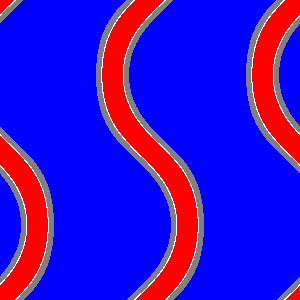

In [95]:
pitch = 1               # [cm]
region1 = Box(pitch, "periodic")

###################### FILL this variables with the volumetric fractions you need ###########################################
clad_dens  = 0.0980
cool_dens  = 0.6898
fuel_dens  = 0.1936
void_dens  = 1 - (clad_dens + cool_dens + fuel_dens)  # gap tra fuel e clad

######################## coolant | clad | gap | fuel | gap | clad | coolant ################################################
iso_clad1  = cool_dens / 2
iso_gap1   = iso_clad1 + clad_dens/2
iso_fuel1  = 0.5 - fuel_dens/2
iso_fuel2  = 0.5 + fuel_dens/2
iso_gap2   = 1 - iso_gap1
iso_clad2  = 1 - iso_clad1

(tpms_clad1, tpms_gap1, tpms_fuel1, tpms_fuel2, tpms_gap2, tpms_clad2) = openmc.TPMS.from_relative_densities( "Gyroid",
    [iso_clad1, iso_gap1, iso_fuel1, iso_fuel2, iso_gap2, iso_clad2], pitch)

# Define cellss
cell_fuel  = openmc.Cell(0, "cFuel", mFuel, region1 & +tpms_fuel1 & -tpms_fuel2)
cell_clad1 = openmc.Cell(1, "cClad", mClad, region1 & +tpms_clad1 & -tpms_gap1)
cell_clad2 = openmc.Cell(2, "cClad", mClad, region1 & +tpms_gap2  & -tpms_clad2)
cell_gap1  = openmc.Cell(3, "cGap",  None,  region1 & +tpms_gap1  & -tpms_fuel1)
cell_gap2  = openmc.Cell(4, "cGap",  None,  region1 & +tpms_fuel2 & -tpms_gap2)
cell_cool  = openmc.Cell(5, "cCool", mCool, region1 & (-tpms_clad1 | +tpms_clad2))

universe = openmc.Universe(0, "universe",[cell_fuel, cell_clad1, cell_clad2, cell_gap1, cell_gap2, cell_cool])
root = openmc.Cell(6, "root", universe, region1)
geometry = openmc.Geometry([root])
geometry.export_to_xml()

plot_xy = openmc.Plot()
plot_xy.basis = 'xy'
plot_xy.origin = (0, 0, 0)
plot_xy.width = (pitch, pitch)
plot_xy.pixels = (300, 300)
plot_xy.color_by = 'material'
plot_xy.colors = {mFuel: 'red', mClad: 'grey', mCool: 'blue'}
openmc.plot_inline(plot_xy)

## Settings

In [96]:
settings = openmc.Settings()
settings.batches = 120
settings.inactive = 10
settings.particles = 10000

# VOLUME calculation
lower_left = [-pitch/2, -pitch/2, -pitch/2]
upper_right = [pitch/2, pitch/2, pitch/2]
vol_calc = openmc.VolumeCalculation(
    domains=[mCool,mClad,mFuel], 
    samples=100_000_000, 
    lower_left=lower_left, 
    upper_right=upper_right
)
settings.volume_calculations = [vol_calc]

settings.export_to_xml()

# Execution of volume calculation
#openmc.calculate_volumes()

## RUN OpenMC

In [97]:
openmc.run(threads=8)

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################